# Пример 07. Собственный вектор с заданной суммой координат

## Тема

**Раздел книги:** Линейная алгебра.  
**Математическая тема:** собственные значения и собственные векторы, нормировка вектора; связь с методом главных компонент (PCA).

## Условие

Для матрицы

$$A = \begin{pmatrix}6 & 4 & 3 \\ 6 & 0 & 9 \\ 0 & 8 & 0\end{pmatrix}$$

требуется найти все $x\in\mathbb{R}^3$, удовлетворяющие условию $Ax = 12x$ при дополнительном ограничении $\sum_{i=1}^{3} x_i = 1$.

## Математическая идея

Уравнение $Ax = \lambda x$ определяет собственные векторы $x$ и собственные значения $\lambda$ матрицы $A$. Если $\lambda = 12$ действительно является собственным значением, то соответствующий собственный вектор находится из системы

$$(A - 12 I)\, x = 0.$$

Собственный вектор определён с точностью до скалярного множителя, поэтому дополнительное условие $\sum x_i = 1$ однозначно фиксирует его.

## Решение

1. Проверяется, что $\lambda = 12$ — собственное значение матрицы $A$.
2. Находится соответствующий собственный вектор (с точностью до множителя).
3. Вектор нормируется так, чтобы сумма его компонент равнялась единице: $x \leftarrow x / \sum x_i$.
4. Проверяется, что $Ax = 12x$ и $\sum x_i = 1$.

## Реализация на Python

Функция `np.linalg.eig(A)` возвращает все собственные значения и собственные векторы. Чтобы выбрать нужный, используется `np.isclose(eigenvalues, 12)` — это сравнение с учётом численной погрешности. Нормировка выполняется через деление на `np.sum(eigenvector)`. Проверка `A @ x` и `12 * x` подтверждает корректность результата.


In [1]:
import numpy as np

# Матрица A и собственное значение
A = np.array([[6, 4, 3],
             [6, 0, 9],
             [0, 8, 0]])

eigenvalue = 12

# Найдем собственный вектор
eigenvectors = np.linalg.eig(A)[1]
eigenvector = eigenvectors[:, np.isclose(np.linalg.eig(A)[0], eigenvalue)].flatten()

# Нормировка под условие суммы = 1
x = eigenvector / np.sum(eigenvector)
print("Решение х =", x)
print("Проверка Ах = ", A @ x)
print("Проверка 12х =", 12 * x)

Решение х = [0.375 0.375 0.25 ]
Проверка Ах =  [4.5 4.5 3. ]
Проверка 12х = [4.5 4.5 3. ]


## Дополнительный пример

**Идея.** В PCA главные компоненты — это собственные векторы ковариационной матрицы данных, упорядоченные по убыванию собственных значений. Каждое собственное значение равно дисперсии данных вдоль соответствующей главной компоненты. Взяв $k$ наибольших, получаем оптимальное $k$-мерное подпространство, в котором сохраняется максимальная дисперсия.

**Что демонстрирует код.** Генерируются двумерные данные (`make_blobs`), вычисляется их ковариационная матрица, и через `np.linalg.eigh` находятся собственные векторы. Сортировка по убыванию собственных значений выбирает первую главную компоненту, и данные проецируются на неё — получается одномерное представление, сохраняющее наибольшую дисперсию.


### 📉 Как собственные векторы применяются в PCA для снижения размерности данных? PCA на реальных данных

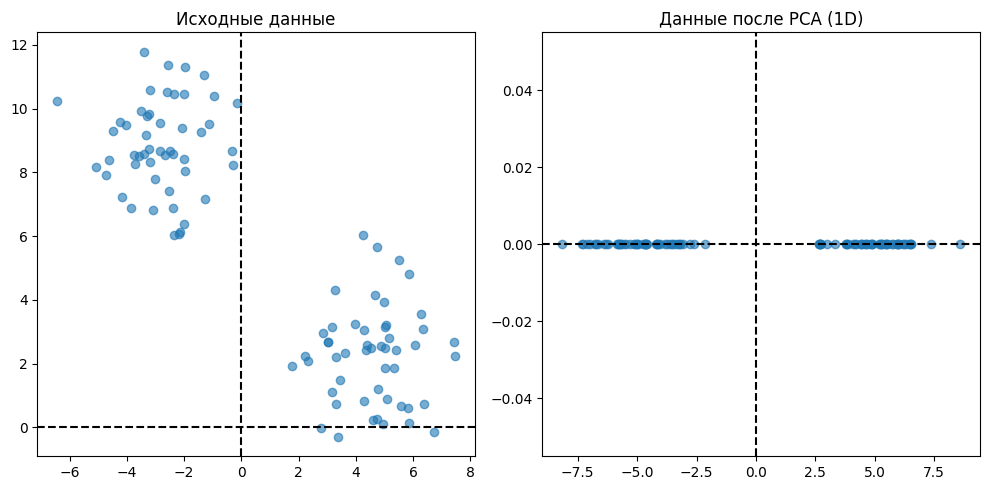

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Сгенерируем данные с 2 признаками
X, _ = make_blobs(n_samples=100, centers=2, cluster_std=1.5, random_state=42)

X_centered = X - np.mean(X, axis=0)

# Вычисляем ковариационную матрицу
cov_matrix = np.cov(X_centered, rowvar=False)

# Находим собственные векторы и значения
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Сортируем собственные векторы по убыванию собственных значений
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvectors = eigenvectors[:, sorted_indices]

# Первый собственный вектор (главная компонента)
v1 = eigenvectors[:, 0]

# Визуализация
plt.figure(figsize=(10, 5))

# До PCA
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], alpha=0.6)
plt.title("Исходные данные")
plt.axhline(0, color='k', linestyle='--')
plt.axvline(0, color='k', linestyle='--')

# После PCA
plt.subplot(1, 2, 2)
plt.scatter(X_centered @ eigenvectors[:, 0], np.zeros_like(X[:, 0]), alpha=0.6)
plt.title("Данные после PCA (1D)")
plt.axhline(0, color='k', linestyle='--')
plt.axvline(0, color='k', linestyle='--')

plt.tight_layout()
plt.show()

## Проверка результата

В первой части проверка состоит в сравнении `A @ x` с `12 * x`: они должны совпасть с точностью до численной погрешности. Дополнительно проверяется, что сумма компонент $x$ равна единице. Во второй части проверка качественная: визуально видно, что проекция данных на первую главную компоненту сохраняет основную структуру (два кластера), а дисперсия вдоль перпендикулярного направления теряется.

## Вывод

Собственные векторы и собственные значения — это не просто абстрактные объекты линейной алгебры: они являются основой метода главных компонент, одного из самых распространённых методов снижения размерности в машинном обучении. Понимание того, как собственный вектор нормируется под дополнительное условие, полезно при работе с распределениями вероятностей (сумма компонент равна 1) и с матрицами перехода в цепях Маркова.
